## 1. Imports

In [2]:
import requests
import pandas as pd

def get_latest_rpi(fallback_rpi=203.6):
    try:
        dataset_id = "d_14f63e595975691e7c24a27ae4c07c79"
        url = "https://data.gov.sg/api/action/datastore_search?resource_id="  + dataset_id
                
        response = requests.get(url)
        print(response.json())

#         data = response.json()
#         df = pd.DataFrame(data['result']['records'])
#         df = df.sort_values('quarter')
        
#         latest_rpi = float(df.iloc[-1]['index'])
#         latest_quarter = df.iloc[-1]['quarter']
#         print(f"✓ Live RPI fetched: {latest_rpi} ({latest_quarter})")
#         return latest_rpi
        
    except Exception as e:
        print(f"⚠ RPI fetch failed: {e}. Using fallback value: 203.6")
        return 203.6

# CURRENT_RPI = get_latest_rpi(fallback_rpi=203.6)

In [3]:
get_latest_rpi(fallback_rpi=203.6)

{'code': 24, 'name': 'TOO_MANY_REQUESTS', 'data': None, 'errorMsg': 'Rate limit exceeded. Please try again in 10 seconds and sign up for an API key at https://data.gov.sg for higher rate limits.'}


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import re

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

## 2. Load Data

In [2]:
# Navigate to project workspace
os.chdir('/workspaces/DSE3101-Project')

# Verify correct directory location 
print("Current directory:", os.getcwd())
print("Contents:", os.listdir('.'))

# Navigate to data/raw folder to obtain zip file that contains raw data
os.chdir('data/raw')
current_dir = os.getcwd()
print(f"Latest directory: {current_dir}")

Current directory: /workspaces/DSE3101-Project
Contents: ['docs', '.git', 'notebooks', '.DS_Store', 'models', 'frontend', 'requirements.txt', '.gitignore', '.vscode', 'backend', 'requirements_fixed.txt', 'Final Web Scraper.ipynb', 'data', 'onemap_all_themes_full.json', 'README.md', 'onemap_all_themes_raw.txt']
Latest directory: /workspaces/DSE3101-Project/data/raw


In [3]:
hdb_df = pd.read_csv('HDB_full_resale_info.csv.gz', compression='gzip')

print(f"Dataframe shape: {hdb_df.shape}")

# Merge RPI (annual average)
rpi_df = pd.read_csv('HousingAndDevelopmentBoardHDBResalePriceIndex1Q2009100Quarterly.csv')
rpi_long = rpi_df.melt(id_vars='DataSeries', var_name='quarter_str', value_name='RPI')
rpi_long = rpi_long[rpi_long['DataSeries'] == 'HDB Resale Price Index'].copy()
rpi_long['sold_year'] = rpi_long['quarter_str'].str[:4].astype(int)
rpi_annual = rpi_long.groupby('sold_year')['RPI'].mean().reset_index()

hdb_df = hdb_df.merge(rpi_annual, on='sold_year', how='left')
hdb_df = hdb_df.dropna(subset=['RPI'])

print(f"After dropping missing RPI: {hdb_df.shape}")
hdb_df.info()

Dataframe shape: (259143, 37)
After dropping missing RPI: (256457, 38)
<class 'pandas.DataFrame'>
RangeIndex: 256457 entries, 0 to 256456
Data columns (total 38 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   town                               256457 non-null  str    
 1   flat_type                          256457 non-null  str    
 2   block                              256457 non-null  str    
 3   street_name                        256457 non-null  str    
 4   storey_range                       256457 non-null  str    
 5   floor_area_sqm                     256457 non-null  float64
 6   flat_model                         256457 non-null  str    
 7   lease_commence_date                256457 non-null  int64  
 8   resale_price                       256457 non-null  float64
 9   remaining_lease                    256457 non-null  int64  
 10  sold_year                          256457 no

## 3. Exploratory Data Analysis

In [4]:
# Missing values
missing_values = hdb_df.isnull().sum()
print("Missing values per column:")
print(missing_values)

# Drop duplicates
print(f"\nDuplicate rows: {hdb_df.duplicated().sum()}")
hdb_df = hdb_df.drop_duplicates()
duplicates_removed = hdb_df.duplicated().sum()
print(f"\nDuplicate rows remaining: {duplicates_removed}")

# Descriptive statistics
display(hdb_df[['floor_area_sqm', 'resale_price', 'remaining_lease', 'sold_year',
                'nearest_mrt_distance_m', 'num_amenities_within_1000m']].describe())

Missing values per column:
town                                 0
flat_type                            0
block                                0
street_name                          0
storey_range                         0
floor_area_sqm                       0
flat_model                           0
lease_commence_date                  0
resale_price                         0
remaining_lease                      0
sold_year                            0
address                              0
max_floor_lvl                        0
storey_mid                           0
storey_category                      0
region                               0
is_mature_estate                     0
latitude                             0
longitude                            0
matched_address                      0
status                               0
nearest_mrt_name                     0
nearest_mrt_distance_m               0
nearest_clinic_name                  0
nearest_clinic_distance_m            

,floor_area_sqm,resale_price,remaining_lease,sold_year,nearest_mrt_distance_m,num_amenities_within_1000m
count,256457.000000,2.564570e+05,256457.000000,256457.000000,256457.000000,256457.000000
mean,96.907870,5.124693e+05,74.222872,2020.401888,606.021257,22.941803
std,24.048654,1.829041e+05,13.737674,3.072595,368.976308,8.675089
min,31.000000,1.400000e+05,40.000000,2015.000000,34.000000,3.000000
25%,81.000000,3.780000e+05,63.000000,2018.000000,322.400000,17.000000
50%,93.000000,4.780000e+05,74.000000,2021.000000,536.600000,22.000000
75%,112.000000,6.150000e+05,87.000000,2023.000000,808.400000,28.000000
max,366.700000,1.658888e+06,98.000000,2025.000000,3574.500000,67.000000


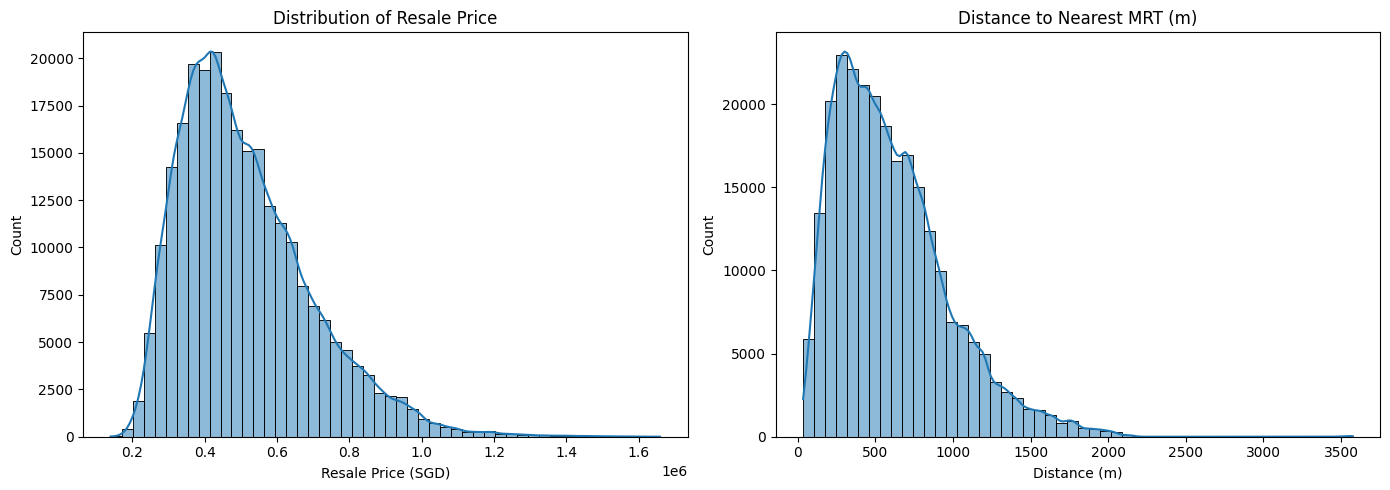

In [5]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(hdb_df['resale_price'], kde=True, bins=50, ax=axes[0])
axes[0].set_title('Distribution of Resale Price')
axes[0].set_xlabel('Resale Price (SGD)')

sns.histplot(hdb_df['nearest_mrt_distance_m'], kde=True, bins=50, ax=axes[1])
axes[1].set_title('Distance to Nearest MRT (m)')
axes[1].set_xlabel('Distance (m)')

plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [6]:
df_model = hdb_df.copy()

# --- Flat age at sale ---
df_model['flat_age_at_sale'] = df_model['sold_year'] - df_model['lease_commence_date']

# --- Normalized log target: remove floor area and time trend via RPI, so the model learns the true price drivers ---
df_model['log_price_norm'] = np.log(df_model['resale_price'] / (df_model['floor_area_sqm'] * df_model['RPI']))

# --- Drop columns: identifiers, leaky, redundant, or raw target ---
cols_to_drop = [
    # Identifiers and raw text
    'address', 'block', 'street_name', 'matched_address',
    'status', 'sold_year_month', 'year',
    # Facility info (strings, not useful for model)
    'nearest_mrt_name', 'nearest_clinic_name', 'nearest_park_name',
    'nearest_community_club_name', 'nearest_hawker_name', 'num_hawker_within_1000m',
    # Raw coordinates (location already captured by town/region
    # and spatial distance features)
    'latitude', 'longitude',
    # Target and RPI (used only to construct log_price_norm)
    'resale_price', 'RPI',
    # NOT available in PropertyGuru listings
    'flat_model',     # HDB architectural model not listed
    'storey_range',   # Replaced by storey_mid + storey_category
    'max_floor_lvl',  # Not available in listings
]

df_model = df_model.drop(columns=[c for c in cols_to_drop if c in df_model.columns])

# --- Encode categorical columns ---
categorical_cols = [
    c for c in df_model.select_dtypes(
        include=['object', 'category']
    ).columns.tolist()
    if c != 'log_price_norm'
]
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le

print(f"Preprocessed shape: {df_model.shape}")
print(f"Columns: {df_model.columns.tolist()}")

/tmp/ipykernel_66375/2239596469.py:32: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  c for c in df_model.select_dtypes(


Preprocessed shape: (256457, 22)
Columns: ['town', 'flat_type', 'floor_area_sqm', 'lease_commence_date', 'remaining_lease', 'sold_year', 'storey_mid', 'storey_category', 'region', 'is_mature_estate', 'nearest_mrt_distance_m', 'nearest_clinic_distance_m', 'nearest_park_distance_m', 'nearest_community_club_distance_m', 'nearest_hawker_distance_m', 'num_mrt_within_1000m', 'num_clinic_within_1000m', 'num_park_within_1000m', 'num_community_club_within_1000m', 'num_amenities_within_1000m', 'flat_age_at_sale', 'log_price_norm']


## 5. Train / Test Split

In [7]:
# Define feature list (everything except the target)
TREE_FEATURES = [c for c in df_model.columns if c != 'log_price_norm']

# ============================================================
# Time-based split instead of random split
# Train on older data, test on most recent data
# This is more realistic for time-series price prediction
# ============================================================
train_mask = df_model['sold_year'] < 2023
test_mask  = df_model['sold_year'] >= 2023

X_train = df_model.loc[train_mask, TREE_FEATURES]
X_test  = df_model.loc[test_mask,  TREE_FEATURES]
y_train = df_model.loc[train_mask, 'log_price_norm']
y_test  = df_model.loc[test_mask,  'log_price_norm']

# Current RPI for converting log predictions back to dollar prices
CURRENT_RPI = 203.6
y_train_actual = np.exp(y_train) * X_train['floor_area_sqm'] * CURRENT_RPI
y_test_actual = np.exp(y_test) * X_test['floor_area_sqm'] * CURRENT_RPI

print(f"Training set: {X_train.shape[0]:,} rows "
      f"(up to year {df_model.loc[train_mask, 'sold_year'].max()})")
print(f"Test set:     {X_test.shape[0]:,} rows "
      f"(from year {df_model.loc[test_mask, 'sold_year'].min()} onwards)")
print(f"Features:     {len(TREE_FEATURES)}")
print(f"\nFeature list:")
for f in TREE_FEATURES:
    print(f"  {f}")          # ← this line was missing

Training set: 178,537 rows (up to year 2022)
Test set:     77,920 rows (from year 2023 onwards)
Features:     21

Feature list:
  town
  flat_type
  floor_area_sqm
  lease_commence_date
  remaining_lease
  sold_year
  storey_mid
  storey_category
  region
  is_mature_estate
  nearest_mrt_distance_m
  nearest_clinic_distance_m
  nearest_park_distance_m
  nearest_community_club_distance_m
  nearest_hawker_distance_m
  num_mrt_within_1000m
  num_clinic_within_1000m
  num_park_within_1000m
  num_community_club_within_1000m
  num_amenities_within_1000m
  flat_age_at_sale


In [8]:
# ============================================================
# Upweight recent transactions more heavily
# because recent market conditions are most relevant
# for predicting current listing prices
# ============================================================
# Sample weights — for better training focus on recent market
sample_weights = 1 + (X_train['sold_year'] - X_train['sold_year'].min()) / \
                     (X_train['sold_year'].max() - X_train['sold_year'].min())
# This gives weight 1.0 to oldest year, 2.0 to most recent training year

# ============================================================
# XGBoost with regularisation and early stopping
#
# min_child_weight=5 : prevents learning from tiny data groups
# gamma=0.1          : node must reduce loss to be split
# reg_alpha=0.1      : L1 regularisation
# reg_lambda=1.0     : L2 regularisation
# early_stopping_rounds=50 : stops when no improvement
# ============================================================
xgb_model = xgb.XGBRegressor(
    n_estimators=3000,
    learning_rate=0.02,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric='rmse'
)

xgb_model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    verbose=100
)

print(f"\nTraining complete!")
print(f"Best iteration: {xgb_model.best_iteration}")

[0]	validation_0-rmse:0.20342
[100]	validation_0-rmse:0.07861
[200]	validation_0-rmse:0.06737
[300]	validation_0-rmse:0.06435
[400]	validation_0-rmse:0.06273
[500]	validation_0-rmse:0.06160
[600]	validation_0-rmse:0.06135
[700]	validation_0-rmse:0.06124
[800]	validation_0-rmse:0.06121
[900]	validation_0-rmse:0.06116
[1000]	validation_0-rmse:0.06114
[1055]	validation_0-rmse:0.06115

Training complete!
Best iteration: 1005


## 7. Evaluation

MAE:  $31,121.33
MAPE: 4.73%


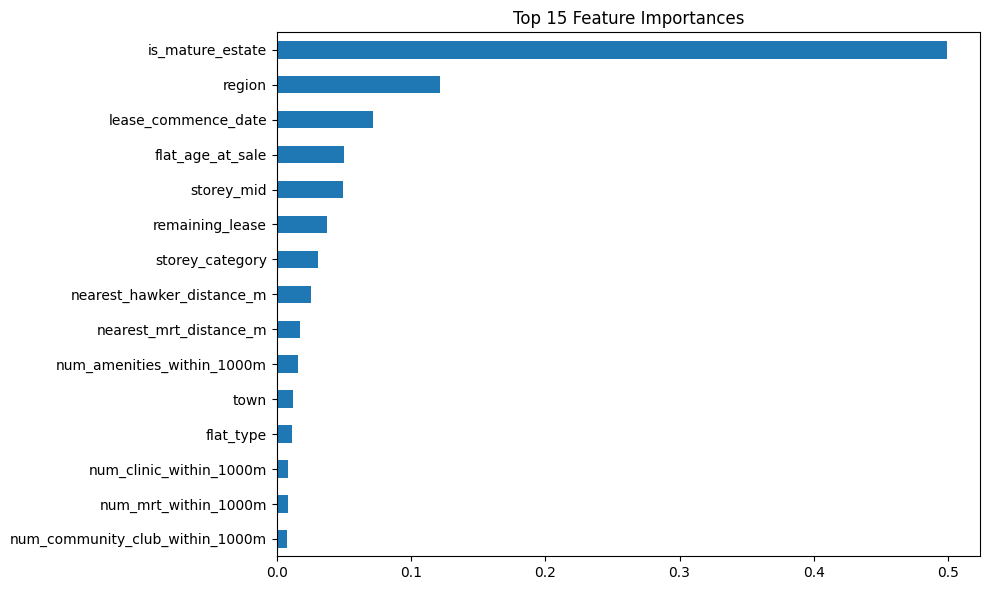


Top 10 features:
is_mature_estate              0.498898
region                        0.121332
lease_commence_date           0.071886
flat_age_at_sale              0.050353
storey_mid                    0.049605
remaining_lease               0.037289
storey_category               0.030582
nearest_hawker_distance_m     0.025395
nearest_mrt_distance_m        0.017454
num_amenities_within_1000m    0.016039
dtype: float32


In [9]:
final_log_preds = xgb_model.predict(X_test)
final_dollar_preds = np.exp(final_log_preds) * X_test['floor_area_sqm'] * CURRENT_RPI

mae  = mean_absolute_error(y_test_actual, final_dollar_preds)
mape = mean_absolute_percentage_error(y_test_actual, final_dollar_preds) * 100

print(f"MAE:  ${mae:,.2f}")
print(f"MAPE: {mape:.2f}%")

# Feature importance
feat_imp = pd.Series(
    xgb_model.feature_importances_,
    index=TREE_FEATURES
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(feat_imp.head(10))

## 8. Prediction Function

In [10]:
# Town-level listing premium
# Converts transacted price → asking/listing price
TOWN_PREMIUM = {
    'MARINE PARADE':     1.17,
    'QUEENSTOWN':        1.15,
    'CLEMENTI':          1.11,
    'BUKIT MERAH':       1.10,
    'BUKIT PANJANG':     1.10,
    'HOUGANG':           1.09,
    'BEDOK':             1.08,
    'KALLANG/WHAMPOA':   1.08,
    'JURONG EAST':       1.07,
    'BUKIT BATOK':       1.07,
    'CENTRAL AREA':      1.07,
    'TAMPINES':          1.07,
    'JURONG WEST':       1.06,
    'CHOA CHU KANG':     1.06,
    'SERANGOON':         1.06,
    'TOA PAYOH':         1.06,
    'PASIR RIS':         1.05,
    'ANG MO KIO':        1.05,
    'WOODLANDS':         1.05,
    'SENGKANG':          1.05,
    'YISHUN':            1.05,
    'BISHAN':            1.04,
    'PUNGGOL':           1.04,
    'BUKIT TIMAH':       1.03,
    'GEYLANG':           1.03,
    'SEMBAWANG':         1.02,
}

DEFAULT_PREMIUM = 1.07

# Flat type adjustment on top of town premium
FLAT_TYPE_ADJUSTMENT = {
    '2 ROOM':           1.035,
    '3 ROOM':           1.014,
    'EXECUTIVE':        1.008,
    '4 ROOM':           0.998,
    '5 ROOM':           0.993,
    'MULTI-GENERATION': 1.000,
}

In [11]:
def _encode_and_predict(input_dict):
    """
    Shared helper used by both prediction functions.
    Encodes categoricals and runs the XGBoost prediction.
    Returns the raw transacted price (before premiums).
    """
    input_df = pd.DataFrame([input_dict])[TREE_FEATURES]

    for col in categorical_cols:
        if col in input_df.columns:
            try:
                input_df[col] = encoders[col].transform(
                    input_df[col].astype(str)
                )
            except ValueError:
                # Unseen category: fall back to first known class
                input_df[col] = encoders[col].transform(
                    [encoders[col].classes_[0]]
                )[0]

    log_pred = xgb_model.predict(input_df)[0]
    return log_pred


# ============================================================
# FUNCTION 1: For PropertyGuru listings dataset
# Uses actual engineered features from the listing row
# Most accurate prediction
# ============================================================
def predict_price_listing(listing_row):
    """
    Takes a single row from the PropertyGuru listings dataframe.
    Missing features are filled with NaN — tree models handle this natively.
    """
    def safe_get(row, key):
        """Return NaN if key is missing or value is None/NaN."""
        try:
            val = row[key]
            return val if pd.notna(val) else np.nan
        except (KeyError, TypeError):
            return np.nan

    input_dict = {
        'town':                              safe_get(listing_row, 'hdb_town'),
        'flat_type':                         safe_get(listing_row, 'flat_type'),
        'floor_area_sqm':                    safe_get(listing_row, 'floor_area_sqm'),
        'lease_commence_date':               safe_get(listing_row, 'lease_commence_date'),
        'remaining_lease':                   safe_get(listing_row, 'remaining_lease'),
        'sold_year':                         safe_get(listing_row, 'sold_year'),
        'storey_mid':                        safe_get(listing_row, 'storey_mid'),
        'storey_category':                   safe_get(listing_row, 'floor_category'),
        'region':                            safe_get(listing_row, 'region'),
        'is_mature_estate':                  safe_get(listing_row, 'is_mature_estate'),
        'nearest_mrt_distance_m':            safe_get(listing_row, 'nearest_mrt_distance_m'),
        'nearest_clinic_distance_m':         safe_get(listing_row, 'nearest_clinic_distance_m'),
        'nearest_park_distance_m':           safe_get(listing_row, 'nearest_park_distance_m'),
        'nearest_community_club_distance_m': safe_get(listing_row, 'nearest_community_club_distance_m'),
        'nearest_hawker_distance_m':         safe_get(listing_row, 'nearest_hawker_distance_m'),
        'num_mrt_within_1000m':              safe_get(listing_row, 'num_mrt_within_1000m'),
        'num_clinic_within_1000m':           safe_get(listing_row, 'num_clinic_within_1000m'),
        'num_park_within_1000m':             safe_get(listing_row, 'num_park_within_1000m'),
        'num_hawker_within_1000m':           safe_get(listing_row, 'num_hawker_within_1000m'),
        'num_community_club_within_1000m':   safe_get(listing_row, 'num_community_club_within_1000m'),
        'num_amenities_within_1000m':        safe_get(listing_row, 'num_amenities_within_1000m'),
        'flat_age_at_sale':                  safe_get(listing_row, 'flat_age_at_sale'),
    }

    log_pred   = _encode_and_predict(input_dict)
    
    # floor_area_sqm is critical for inverse transform — fall back to flat type median if missing
    floor_area = safe_get(listing_row, 'floor_area_sqm')
    if np.isnan(floor_area):
        FLAT_TYPE_MEDIAN_SQM = {
            '2 ROOM': 45, '3 ROOM': 67, '4 ROOM': 90,
            '5 ROOM': 110, 'EXECUTIVE': 130
        }
        floor_area = FLAT_TYPE_MEDIAN_SQM.get(listing_row.get('flat_type', ''), 90)

    transacted = np.exp(log_pred) * floor_area * CURRENT_RPI

    listing_premium = TOWN_PREMIUM.get(safe_get(listing_row, 'hdb_town'), DEFAULT_PREMIUM)
    flat_adj        = FLAT_TYPE_ADJUSTMENT.get(safe_get(listing_row, 'flat_type'), 1.0)

    return round(transacted * listing_premium * flat_adj, 2)

# ============================================================
# FUNCTION 2: For user-facing price estimator
# Takes only 4-5 inputs, imputes missing features smartly
# Returns price with confidence range to reflect uncertainty
# ============================================================
def predict_price_user(town, flat_type, floor_area, sold_year,
                       remaining_lease=None):
    """
    Takes minimal user inputs and estimates the resale price.
    Uses town + flat_type historical medians for missing features.
    Returns a dict with estimated price and confidence range.

    Usage:
        result = predict_price_user('QUEENSTOWN', '4 ROOM', 83, 2025,
                                     remaining_lease=68)
        print(result['estimated_price'])
        print(result['lower_bound'])
        print(result['upper_bound'])
    """

    # ============================================================
    # Get best matching historical reference data for imputation
    # Priority: town + flat_type + recent → town + flat_type → town
    # ============================================================
    ref = hdb_df[
        (hdb_df['town'] == town) &
        (hdb_df['flat_type'] == flat_type) &
        (hdb_df['sold_year'] >= 2022)
    ]
    if ref.empty:
        ref = hdb_df[
            (hdb_df['town'] == town) &
            (hdb_df['flat_type'] == flat_type)
        ]
    if ref.empty:
        ref = hdb_df[hdb_df['town'] == town]
    if ref.empty:
        ref = hdb_df.copy()

    # ============================================================
    # Impute lease features
    # Use user-provided remaining_lease if given, otherwise median
    # ============================================================
    if remaining_lease is None:
        remaining_lease = int(ref['remaining_lease'].median())

    flat_age       = 99 - remaining_lease
    lease_commence = sold_year - flat_age

    # ============================================================
    # Build input using actual user values + imputed medians
    # ============================================================
    input_dict = {
        'town':                              town,
        'flat_type':                         flat_type,
        'floor_area_sqm':                    floor_area,
        'lease_commence_date':               lease_commence,
        'remaining_lease':                   remaining_lease,
        'sold_year':                         sold_year,
        'storey_mid':                        ref['storey_mid'].median(),
        'storey_category':                   ref['storey_category'].mode()[0],
        'region':                            ref['region'].mode()[0],
        'is_mature_estate':                  int(ref['is_mature_estate'].mode()[0]),
        'nearest_mrt_distance_m':            ref['nearest_mrt_distance_m'].median(),
        'nearest_clinic_distance_m':         ref['nearest_clinic_distance_m'].median(),
        'nearest_park_distance_m':           ref['nearest_park_distance_m'].median(),
        'nearest_community_club_distance_m': ref['nearest_community_club_distance_m'].median(),
        'nearest_hawker_distance_m':         ref['nearest_hawker_distance_m'].median(),
        'num_mrt_within_1000m':              ref['num_mrt_within_1000m'].median(),
        'num_clinic_within_1000m':           ref['num_clinic_within_1000m'].median(),
        'num_park_within_1000m':             ref['num_park_within_1000m'].median(),
        'num_hawker_within_1000m':           ref['num_hawker_within_1000m'].median(),
        'num_community_club_within_1000m':   ref['num_community_club_within_1000m'].median(),
        'num_amenities_within_1000m':        ref['num_amenities_within_1000m'].median(),
        'flat_age_at_sale':                  flat_age,
    }

    log_pred   = _encode_and_predict(input_dict)
    transacted = np.exp(log_pred) * floor_area * CURRENT_RPI

    listing_premium = TOWN_PREMIUM.get(town, DEFAULT_PREMIUM)
    flat_adj        = FLAT_TYPE_ADJUSTMENT.get(flat_type, 1.0)
    estimated_price = transacted * listing_premium * flat_adj

    # ============================================================
    # Return price with +/- (rounded mape)% confidence range
    # This honestly reflects the uncertainty from model
    # ============================================================
    mape_val = mape / 100
    return {
        'estimated_price': round(estimated_price, 2),
        'lower_bound':     round(estimated_price * (1-mape_val), 2),
        'upper_bound':     round(estimated_price * (1+mape_val), 2),
        'note': (
            f"Estimated based on {town} {flat_type} historical averages. "
            f"Actual price may vary depending on floor level, exact location, "
            f"and remaining lease."
        )
    }

## 9. Example Predictions

In [12]:
# With remaining lease
result = predict_price_user(
    town='QUEENSTOWN',
    flat_type='4 ROOM',
    floor_area=98,
    sold_year=2026,
    remaining_lease=68
)
print(f"Estimated Price:  ${result['estimated_price']:,.0f}")
print(f"Confidence Range: ${result['lower_bound']:,.0f} – "
      f"${result['upper_bound']:,.0f}")
print(f"Note: {result['note']}")

# Without remaining lease (uses town median as fallback)
result2 = predict_price_user(
    town='QUEENSTOWN',
    flat_type='4 ROOM',
    floor_area=98,
    sold_year=2026
)
print(f"\nEstimated Price (no lease):  ${result2['estimated_price']:,.0f}")
print(f"Confidence Range:            ${result2['lower_bound']:,.0f} – "
      f"${result2['upper_bound']:,.0f}")

Estimated Price:  $965,220
Confidence Range: $919,537 – $1,010,903
Note: Estimated based on QUEENSTOWN 4 ROOM historical averages. Actual price may vary depending on floor level, exact location, and remaining lease.

Estimated Price (no lease):  $1,260,655
Confidence Range:            $1,200,990 – $1,320,321


In [13]:
export_artifacts = {
    'xgb_model':        xgb_model,
    'hdb_df':           hdb_df,
    'X_train':          X_train,
    'encoders':         encoders,
    'TREE_FEATURES':    TREE_FEATURES,
    'categorical_cols': categorical_cols,
    'CURRENT_RPI':      CURRENT_RPI,
}

joblib.dump(export_artifacts, 'hdb_model_artifacts_v2.pkl', compress=9)
print("Model artifacts saved to hdb_model_artifacts_v2.pkl")

Model artifacts saved to hdb_model_artifacts_v2.pkl


In [19]:
## 11. Test Predictions Against Real Listings

listings_df = pd.read_csv('hdb_listings.csv')

# Clean floor area
listings_df['floorArea'] = listings_df['floorArea'].astype(str).str.replace(' sqm', '').str.strip()
listings_df['floorArea'] = pd.to_numeric(listings_df['floorArea'], errors='coerce')

# Map flat types to training format
flattype_map = {
    '2-Room': '2 ROOM', '3-Room': '3 ROOM', '4-Room': '4 ROOM',
    '5-Room': '5 ROOM', 'Executive': 'EXECUTIVE', 'Multi-Generation': 'MULTI-GENERATION',
}

# Map town names to training format
town_map = {
    'Ang Mo Kio': 'ANG MO KIO', 'Bedok': 'BEDOK', 'Bishan': 'BISHAN',
    'Bukit Batok': 'BUKIT BATOK', 'Bukit Merah': 'BUKIT MERAH',
    'Bukit Panjang': 'BUKIT PANJANG', 'Bukit Timah': 'BUKIT TIMAH',
    'Central': 'CENTRAL AREA', 'Choa Chu Kang': 'CHOA CHU KANG',
    'Clementi': 'CLEMENTI', 'Geylang': 'GEYLANG', 'Hougang': 'HOUGANG',
    'Jurong East': 'JURONG EAST', 'Jurong West': 'JURONG WEST',
    'Kallang/Whampoa': 'KALLANG/WHAMPOA', 'Marine Parade': 'MARINE PARADE',
    'Pasir Ris': 'PASIR RIS', 'Punggol': 'PUNGGOL', 'Queenstown': 'QUEENSTOWN',
    'Sembawang': 'SEMBAWANG', 'Sengkang': 'SENGKANG', 'Serangoon': 'SERANGOON',
    'Tampines': 'TAMPINES', 'Toa Payoh': 'TOA PAYOH', 'Woodlands': 'WOODLANDS',
    'Yishun': 'YISHUN',
}

listings_df['town_mapped'] = listings_df['town'].map(town_map)
listings_df['flattype_mapped'] = listings_df['flatType'].map(flattype_map)

valid_towns = set(hdb_df['town'].unique())
valid_flattypes = set(hdb_df['flat_type'].unique())

listings_clean = listings_df[
    listings_df['town_mapped'].isin(valid_towns) &
    listings_df['flattype_mapped'].isin(valid_flattypes) &
    listings_df['floorArea'].notna() &
    listings_df['price'].notna() &
    listings_df['maxRemainingLease'].notna()
].copy()

print(f"Valid listings for testing: {len(listings_clean)}")

Valid listings for testing: 2095


In [20]:
listings_clean.columns.tolist()

['address',
 'listingType',
 'hdbCategory',
 'region',
 'coordinates',
 'town',
 'maxRemainingLease',
 'distance',
 'price',
 'photo',
 'flatType',
 'listingId',
 'maxFlatType',
 'maxPrice',
 'creationDate',
 'floorArea',
 'town_mapped',
 'flattype_mapped']

In [21]:
listings_clean = listings_clean.rename(columns={
    'town':      'hdb_town',
    'flatType':  'flat_type',
    'floorArea': 'floor_area_sqm',
    'maxRemainingLease': 'remaining_lease',
    # 'region' stays as 'region' — no change needed
})

In [24]:
# Run predictions
# Apply to all PropertyGuru listings at once
listings_clean['predicted_price'] = listings_clean.apply(
    predict_price_listing, axis=1
)

results = []
for _, row in listings_clean.iterrows():
    try:
        predicted = row['predicted_price']
        actual    = float(row['price'])
        error     = predicted - actual
        pct_error = (error / actual) * 100

        results.append({
            'address':         row['address'],
            'town':            row['hdb_town'],
            'floor_area':      row['floor_area_sqm'],
            'remaining_lease': row['remaining_lease'],
            'actual_price':    actual,
            'predicted_price': predicted,
            'error':           error,
            'pct_error':       pct_error,
            'abs_pct_error':   abs(pct_error),
        })
    except Exception as e:
        print(f"Skipped: {e}")

results_df = pd.DataFrame(results)

print(f"\n=== Prediction vs Listing Price ===")
print(f"Listings tested:  {len(results_df):,}")
print(f"Mean error:       ${results_df['error'].mean():+,.0f}")
print(f"Median abs error: ${results_df['error'].abs().median():,.0f}")
print(f"MAE:              ${results_df['error'].abs().mean():,.0f}")
print(f"MAPE:             {results_df['abs_pct_error'].mean():.1f}%")

print(f"\n=== Error by Town (mean % error) ===")
print(results_df.groupby('hdb_town')['pct_error'].mean()
      .sort_values().round(1).to_string())

# print(f"\n=== Error by Flat Type (mean % error) ===")
# print(results_df.groupby('flat_type')['pct_error'].mean()
#       .sort_values().round(1).to_string())


=== Prediction vs Listing Price ===
Listings tested:  2,095
Mean error:       $+349,114
Median abs error: $353,458
MAE:              $368,103
MAPE:             56.0%

=== Error by Town (mean % error) ===


KeyError: 'hdb_town'